The Expectation-Maximization (EM) technique and Atlas-Based Image Segmentation.
  The segmentation process examines several parameter initialization strategies, each of which is described and put into practice in the sections that follow.
 We start by defining a series of helper functions that serve as crucial building elements to enable the segmentation pipeline.  As defined in the beginning cells, these functions manage duties like intensity normalization, evaluation metrics (like the Dice coefficient), file management (like saving segmented results), utility actions (like extracting identifiers from filenames), and so forth.  As shown below, the implementations are divided into discrete portions, each of which focuses on a particular segmentation strategy or method.  Furthermore, a function is provided to show the segmented image in order to illustrate the segmentation findings for each region. Additionally, to demonstrate the segmentation results for each section, a function is defined to display the segmented image alongside its corresponding ground truth. For demonstration purposes, we selected one image from each section that achieved better Dice scores across the three tissue types (CSF, WM, GM).

In [1]:
#Mounting my drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.2 MB/s eta 0:00:00


##**Segmentation without EM**

In [3]:
# Import libraries
import SimpleITK as sitk
import nibabel as nib
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal, norm
import glob
import nibabel as nib
import re
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter


In [4]:
def display_segmentation_and_ground_truth(segmentation_path, ground_truth_path, slice_index=None):
  segmented_image = sitk.ReadImage(segmentation_path)
  segmented_array = sitk.GetArrayFromImage(segmented_image)
  ground_truth_image = sitk.ReadImage(ground_truth_path)
  ground_truth_array = sitk.GetArrayFromImage(ground_truth_image)
  # Print spatial information to check alignment
  print("Segmentation Image Info:")
  print(segmented_image.GetOrigin(), segmented_image.GetSpacing(), segmented_image.GetDirection())
  print("Ground Truth Image Info:")
  print(ground_truth_image.GetOrigin(), ground_truth_image.GetSpacing(), ground_truth_image.GetDirection())
  # Use the specified slice index or default to the middle slice
  if slice_index is None:
      slice_index = segmented_array.shape[0] // 2
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(segmented_array[slice_index, :, :], cmap="gray")
  plt.title("Segmentation Result")
  plt.axis("off")
  plt.subplot(1, 2, 2)
  plt.imshow(ground_truth_array[slice_index, :, :], cmap="gray")
  plt.title("Ground Truth")
  plt.axis("off")
  plt.show()

In [5]:
def load_tissue_model(tissue_model_folder, tissue_model_file="tissue_distributions.npz"):
  tissue_model_path = os.path.join(tissue_model_folder, tissue_model_file)
  data = np.load(tissue_model_path)
  return data['tissue_distributions']

In [6]:
def min_max_scaler(img, max_val):
  img = img.astype(np.float32)
  minimum = np.min(img)
  maximum = np.max(img)
  if maximum == minimum:
      print("The input is constant or empty. Returning original image.")
      return img
  # Rescale the image
  min_max_scaled = max_val * ((img - minimum) / (maximum - minimum))
  return min_max_scaled

In [7]:
def dice_coefficient(segmented, ground_truth, label):
  segmented_binary = (segmented == label).astype(np.uint8)
  ground_truth_binary = (ground_truth == label).astype(np.uint8)
  intersection = np.sum(segmented_binary * ground_truth_binary)
  return (2. * intersection) / (np.sum(segmented_binary) + np.sum(ground_truth_binary))

In [8]:
def save_segmented_image(segmented_img, img_path, output_folder):
  seg_image_sitk = sitk.GetImageFromArray(segmented_img.astype(np.uint8))
  original_image_sitk = sitk.ReadImage(img_path)
  seg_image_sitk.CopyInformation(original_image_sitk)
  output_seg_path = os.path.join(output_folder, f'segmented_{os.path.basename(img_path)}')
  sitk.WriteImage(seg_image_sitk, output_seg_path)
  print(f'Segmented image saved to {output_seg_path}\n')


In [9]:
# Define the data folders
test_image_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-images/"
csf_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_atlas/csf/"
wm_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_atlas/wm/"
gm_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_atlas/gm/"
mask_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-mask/"
ground_truth_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/"
output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_em_results/"
mni_csf_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/csf_mni/"
mni_wm_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/wm_mni/"
mni_gm_folder = "/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/gm_mni/"
tissue_model_folder = "/content/drive/My Drive/Colab Notebooks/MIRA/Final_ATLAS_Project/tissue_histograms/"
atlas_path = '/content/drive/My Drive/Colab Notebooks/MISA/MNITemplateAtlas/atlas.nii.gz'


###**Extract, scale, and save individual tissue probability maps from the MNI probabilistic atlas**


In [10]:
def split_and_save_probability_maps(atlas_path, output_paths, scale_factor=1000):
    """
    Splits a 4D mini atlas into separate probability maps for each tissue class
    and saves them as individual NIFTI files.
    Parameter: scale_factor (int): Factor to scale probability maps (default is 1000).
    """
    # Load the atlas data and affine
    atlas_img = nib.load(atlas_path)
    atlas_data = atlas_img.get_fdata()
    template_affine = atlas_img.affine

    # Process each label's probability map
    for i, (label, output_path) in enumerate(output_paths.items()):
        output_file = Path(output_path)
        if output_file.exists():
            print(f"{output_path} already exists. Skipping...")
            continue
        probability_map = atlas_data[..., i] * scale_factor

        # Create a new NIFTI image using the probability map and affine from the atlas
        probability_img = nib.Nifti1Image(probability_map, affine=template_affine)
        nib.save(probability_img, str(output_file))
        print(f"Saved {output_file}")

# Define the output paths
output_paths = {
    'mni_background': '/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_background_prob.nii.gz',
    'mni_CSF': '/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_CSF_prob.nii.gz',
    'mni_GM': '/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_GM_prob.nii.gz',
    'mni_WM': '/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_WM_prob.nii.gz'
}

split_and_save_probability_maps(atlas_path, output_paths)


/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_background_prob.nii.gz already exists. Skipping...
/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_CSF_prob.nii.gz already exists. Skipping...
/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_GM_prob.nii.gz already exists. Skipping...
/content/drive/My Drive/Colab Notebooks/MISA/transformed_mini_atlas_labels/mni_WM_prob.nii.gz already exists. Skipping...


###**Tissue models: based Segmentation**

In [11]:
def tissue_model_segmentation(image_folder, mask_folder, label_folder, output_folder, tissue_model_folder, num_bins=4096):
  tissue_model_probs = load_tissue_model(tissue_model_folder)
  os.makedirs(output_folder, exist_ok=True)
    # Lists to store Dice scores
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []
  # Load paths for test images, masks, and labels
  image_paths = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.nii.gz')])
  mask_paths = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith('.nii.gz')])
  label_paths = sorted([os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.nii.gz')])
  for img_path, mask_path, lbl_path in zip(image_paths, mask_paths, label_paths):
    test_img = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    test_img_scaled = min_max_scaler(test_img, num_bins - 1).astype(np.uint16)
    mask_img = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool)
    label_img = sitk.GetArrayFromImage(sitk.ReadImage(lbl_path))

    # Apply mask to define ROI
    ROI = mask_img & (label_img != 0)
    # Reshape probabilities for CSF, WM, and GM based on tissue model
    cond_prob_csf = tissue_model_probs[0, test_img_scaled]
    cond_prob_wm = tissue_model_probs[1, test_img_scaled]
    cond_prob_gm = tissue_model_probs[2, test_img_scaled]

    # Stack conditional probabilities and apply segmentation based on max probability
    stacked_probs = np.stack([cond_prob_csf, cond_prob_wm, cond_prob_gm], axis=0)
    segmented_img = np.argmax(stacked_probs, axis=0) + 1  # +1 to match label convention (1: CSF, 2: WM, 3: GM)
    segmented_img[~ROI] = 0  # Set outside ROI to background
    # Convert the segmented image to a compatible data type
    segmented_img = segmented_img.astype('float32')
    # Calculate Dice Similarity Coefficient for CSF, WM, and GM using the defined function
    dice_csf = dice_coefficient(segmented_img, label_img, label=1)  # CSF
    dice_wm = dice_coefficient(segmented_img, label_img, label=2)   # WM
    dice_gm = dice_coefficient(segmented_img, label_img, label=3)   # GM
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f'Dice Scores for {os.path.basename(img_path)}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}')
    #save segmented result
    save_segmented_image(segmented_img, img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)

  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)

  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)

  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")
# Define output folder
output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/"

tissue_model_segmentation(test_image_folder , mask_folder, ground_truth_folder, output_folder, tissue_model_folder)


Dice Scores for 1003.nii.gz: CSF 0.071, WM 0.889, GM 0.795
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.083, WM 0.753, GM 0.664
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.367, WM 0.899, GM 0.809
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.133, WM 0.912, GM 0.840
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.058, WM 0.824, GM 0.741
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_segmentaion_results/segmented_1019.nii.gz

Dice Scores for 1023.nii.gz: CSF 0.084, WM 0.892, 

Segmentation Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


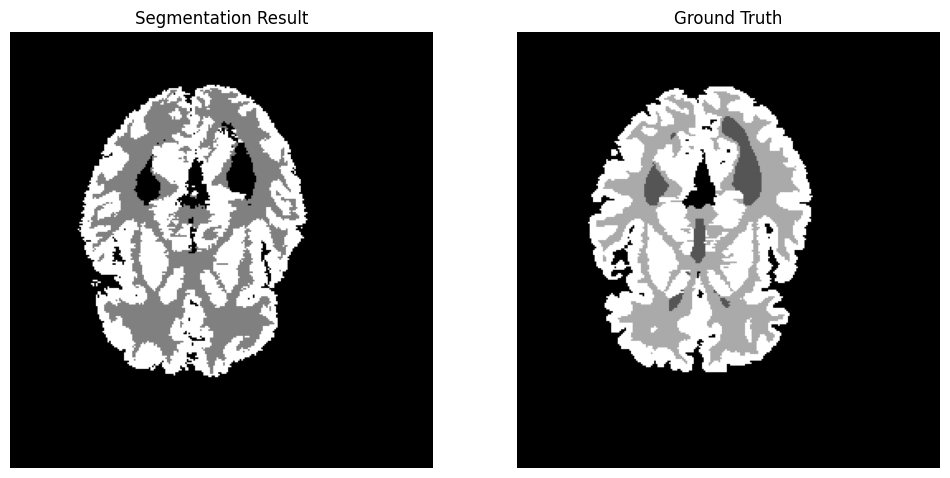

In [12]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_tissue_position_combined_segmentation_results/combined_segmented_1125.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1125_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)


##**Label_propagation  based seegmentation**

In [13]:
def segment_with_label_propagation(test_image_paths, csf_folder, wm_folder, gm_folder, mask_paths, ground_truth_paths, output_folder):
  """
  Performs label propagation segmentation using transformed probability maps for CSF, WM, GM.
  Outputs segmented results and calculates Dice scores.
  """
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  for i, test_image_path in enumerate(test_image_paths):
    # Extract base name without extensions
    base_name = os.path.splitext(os.path.splitext(os.path.basename(test_image_path))[0])[0]

    # Dynamically construct paths for CSF, WM, and GM probability maps
    csf_prob_map_path = os.path.join(csf_folder, f"{base_name}_csf.nii")
    wm_prob_map_path = os.path.join(wm_folder, f"{base_name}_wm.nii")
    gm_prob_map_path = os.path.join(gm_folder, f"{base_name}_gm.nii")

    # Validate the existence of probability map files
    if not os.path.exists(csf_prob_map_path) or not os.path.exists(wm_prob_map_path) or not os.path.exists(gm_prob_map_path):
      raise FileNotFoundError(f"One of the probability maps does not exist:\n"
                              f"CSF: {csf_prob_map_path}\n"
                              f"WM: {wm_prob_map_path}\n"
                              f"GM: {gm_prob_map_path}")
    # Load the probability maps
    csf_prob_map = sitk.ReadImage(csf_prob_map_path)
    wm_prob_map = sitk.ReadImage(wm_prob_map_path)
    gm_prob_map = sitk.ReadImage(gm_prob_map_path)

    csf_array = sitk.GetArrayFromImage(csf_prob_map)
    wm_array = sitk.GetArrayFromImage(wm_prob_map)
    gm_array = sitk.GetArrayFromImage(gm_prob_map)

    # Load mask and apply it for skull stripping
    if mask_paths:
      mask = sitk.ReadImage(mask_paths[i])
      mask_array = sitk.GetArrayFromImage(mask).astype(bool)
    else:
      mask_array = np.ones_like(csf_array, dtype=bool)

    # If ground truth exists, process it to focus only on labeled regions
    if ground_truth_paths:
      ground_truth = sitk.ReadImage(ground_truth_paths[i])
      ground_truth_array = sitk.GetArrayFromImage(ground_truth)

      # Mask ground truth: Keep only labels 1, 2, and 3, set others to 0
      valid_labels = {1, 2, 3}
      ground_truth_array = np.where(np.isin(ground_truth_array, list(valid_labels)), ground_truth_array, 0)

      # Define ROI: focus on labeled regions within the mask
      ROI = mask_array & (ground_truth_array != 0)
    else:
      ROI = mask_array  # Default to mask-only ROI if no ground truth is provided

    # Apply ROI to the probability maps
    csf_array[~ROI] = 0
    wm_array[~ROI] = 0
    gm_array[~ROI] = 0

    # Stack the probability maps and find the label with the highest probability
    stacked_probs = np.stack([csf_array, wm_array, gm_array], axis=0)
    segmented_img = np.argmax(stacked_probs, axis=0) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    segmented_img[~ROI] = 0  # Set regions outside ROI to background

    # Mask segmented result: Keep only labels 1, 2, and 3, set others to 0
    segmented_img = np.where(np.isin(segmented_img, [1, 2, 3]), segmented_img, 0)

    # Calculate Dice scores if ground truth is provided
    if ground_truth_paths:
      dice_csf = dice_coefficient(segmented_img, ground_truth_array, label=1)
      dice_wm = dice_coefficient(segmented_img, ground_truth_array, label=2)
      dice_gm = dice_coefficient(segmented_img, ground_truth_array, label=3)
      # Sore Dice scores in the respective lists
      dice_scores_csf.append(dice_csf)
      dice_scores_wm.append(dice_wm)
      dice_scores_gm.append(dice_gm)

      # Display Dice scores for each class in one line
      print(f'Dice Scores for {os.path.basename(test_image_path)}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}')
        # Save segmented result
    save_segmented_image(segmented_img, test_image_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)

  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)

  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)

  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

# Define paths
output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/"

# Collect file paths for test images, masks, and ground truth
test_image_paths = sorted([os.path.join(test_image_folder, f) for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
mask_paths = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith(".nii.gz")]) if os.path.exists(mask_folder) else None
ground_truth_paths = sorted([os.path.join(ground_truth_folder, f) for f in os.listdir(ground_truth_folder) if f.endswith(".nii.gz")])

segment_with_label_propagation(test_image_paths, csf_folder, wm_folder, gm_folder, mask_paths, ground_truth_paths, output_folder)


Dice Scores for 1003.nii.gz: CSF 0.223, WM 0.768, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.317, WM 0.777, GM 0.796
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.584, WM 0.742, GM 0.782
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.341, WM 0.766, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.292, WM 0.749, GM 0.791
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_segment_results/segmented_1019.nii.gz

Dice Scores for 1023.nii.

Segmentation Image Info:
(-127.5, 127.5, -144.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -144.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


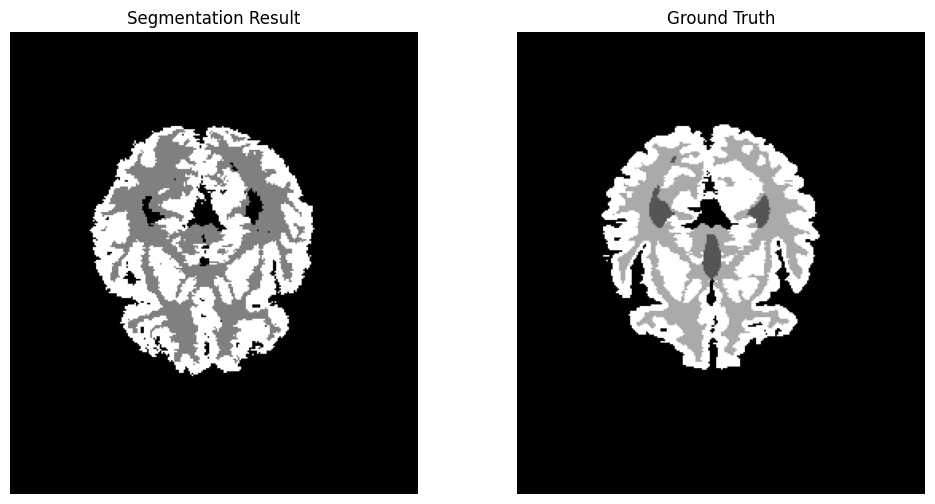

In [14]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_tissue_position_combined_segmentation_results/combined_segmented_1119.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1119_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

###**Label_propagation and Tissue Models Segmentation**

In [15]:
def tissue_model_with_label_propagation(
  test_image_folder,
  mask_folder,
  label_folder,
  output_folder,
  tissue_model_path,
  csf_folder,
  wm_folder,
  gm_folder,
  num_bins=4096,
):
  """
  Perform segmentation using tissue model probabilities and atlas-based spatial probabilities.
  """
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []


  tissue_model_distributions = load_tissue_model(tissue_model_folder)

  csf_model, wm_model, gm_model = (
    tissue_model_distributions[0],  # CSF distribution
    tissue_model_distributions[1],  # WM distribution
    tissue_model_distributions[2],  # GM distribution
  )

  # Helper to extract the identifier (e.g., 1003 from 1003.nii.gz)
  def extract_identifier(filename):
    return filename.split(".")[0]

  # Collect test, label, and mask files
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])

  # Process each test image
  for test_filename in test_files:
    identifier = extract_identifier(test_filename)

    # Find corresponding label and mask files
    label_filename = next((f for f in label_files if f.startswith(identifier) and "3C" in f), None)
    mask_filename = next((f for f in mask_files if f.startswith(identifier) and "1C" in f), None)

    if not label_filename or not mask_filename:
        print(f"Warning: Missing label or mask for test image {test_filename}. Skipping...")
        continue

    # Construct paths for test image, label, mask, and atlas probability maps
    test_img_path = os.path.join(test_image_folder, test_filename)
    label_img_path = os.path.join(label_folder, label_filename)
    mask_img_path = os.path.join(mask_folder, mask_filename)

    csf_prob_map_path = os.path.join(csf_folder, f"{identifier}_csf.nii")
    wm_prob_map_path = os.path.join(wm_folder, f"{identifier}_wm.nii")
    gm_prob_map_path = os.path.join(gm_folder, f"{identifier}_gm.nii")

    # Validate existence of atlas probability maps
    if not os.path.exists(csf_prob_map_path) or not os.path.exists(wm_prob_map_path) or not os.path.exists(gm_prob_map_path):
        print(f"Warning: Missing atlas probability map(s) for test image {test_filename}. Skipping...")
        continue

    # Load test image, label, mask, and atlas probability maps
    test_img = sitk.ReadImage(test_img_path)
    label_img = sitk.ReadImage(label_img_path)
    mask_img = sitk.ReadImage(mask_img_path)

    test_img_array = sitk.GetArrayFromImage(test_img).astype(np.float32)
    label_img_array = sitk.GetArrayFromImage(label_img)
    mask_array = sitk.GetArrayFromImage(mask_img)

    csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(csf_prob_map_path))
    wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(wm_prob_map_path))
    gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(gm_prob_map_path))

    # Apply skull stripping based on the mask
    ROI = mask_array > 0
    test_img_array[~ROI] = 0

    # Normalize intensities to match histogram bins
    max_intensity = len(csf_model) - 1
    test_img_array = np.clip(test_img_array, 0, max_intensity).astype(np.uint16)

    # Calculate conditional probabilities from tissue models
    cond_prob_csf = csf_model[test_img_array]
    cond_prob_wm = wm_model[test_img_array]
    cond_prob_gm = gm_model[test_img_array]

    # Combine intensity and spatial probabilities by multiplication
    combined_prob_csf = cond_prob_csf * csf_prob_map
    combined_prob_wm = cond_prob_wm * wm_prob_map
    combined_prob_gm = cond_prob_gm * gm_prob_map

    # Stack combined probabilities and perform segmentation based on max probability
    stacked_probs = np.stack([combined_prob_csf, combined_prob_wm, combined_prob_gm], axis=0)
    segmented_img = np.argmax(stacked_probs, axis=0) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    segmented_img[~ROI] = 0

    # Mask ground truth for consistency
    valid_labels = {1, 2, 3}
    label_img_array = np.where(np.isin(label_img_array, list(valid_labels)), label_img_array, 0)

    # Mask segmented result
    segmented_img = np.where(np.isin(segmented_img, list(valid_labels)), segmented_img, 0)

    # Calculate Dice Similarity Coefficient
    dice_csf = dice_coefficient(segmented_img, label_img_array, label=1)
    dice_wm = dice_coefficient(segmented_img, label_img_array, label=2)
    dice_gm = dice_coefficient(segmented_img, label_img_array, label=3)

    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)

    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")
    # Save segmented image using the predefined function
    save_segmented_image(segmented_img, test_img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)

  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)

  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)

  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

 # Define the paths

output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/"

tissue_model_with_label_propagation(
    test_image_folder, mask_folder, ground_truth_folder, output_folder, tissue_model_folder, csf_folder, wm_folder, gm_folder
)


Dice Scores for 1003.nii.gz: CSF 0.223, WM 0.768, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.317, WM 0.777, GM 0.796
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.613, WM 0.742, GM 0.783
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.341, WM 0.766, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.292, WM 0.749, GM 0.791
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmente

Segmentation Image Info:
(-127.5, 127.5, -154.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -154.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


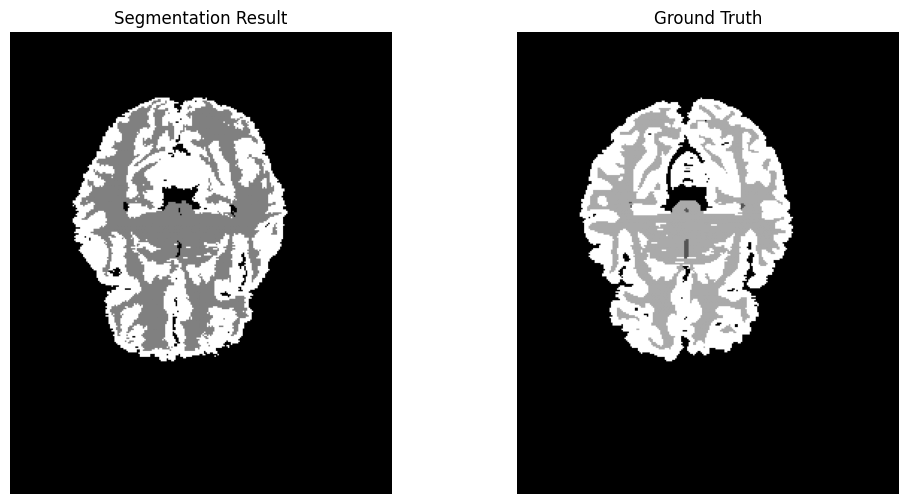

In [16]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/test-set_tissue_position_combined_segmentation_results/combined_segmented_1004.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1004_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

# **Segmetnation with EM**

###**EM: with Differnet Initializations**

In [17]:
def extract_numeric_part(filename):
  """Extract the numeric part from a filename."""
  return "".join([c for c in filename if c.isdigit()])

In [18]:
# Gaussian Mixture Model PDF
def gaussian_mixture(data_vector, mean, std_dev, proportion, num_clusters):
  GMM = np.zeros((data_vector.shape[0], num_clusters))
  for i in range(num_clusters):
      GMM[:, i] = proportion[i] * norm.pdf(data_vector, mean[i], std_dev[i])
  return GMM

In [19]:
# EM Segmentation Function
def em_tissue_segmentation(test_image, initial_labels):
  cluster_numbers = 3
  stopping_threshold = 0.05
  test_image = min_max_scaler(test_image, 255)
  max_iter = 10 #100, 50

  test_3d = test_image.flatten()
  init_3d = initial_labels.flatten()

  # Getting the index of each tissue from the initialization image
  index_CSF = np.where(init_3d== 1)[0]
  index_WM = np.where(init_3d == 2)[0]
  index_GM = np.where(init_3d == 3)[0]

  index_3d = np.concatenate([index_CSF, index_WM, index_GM])

  # Getting the intensity from the index of specific tissue
  data_CSF = test_3d[index_CSF]
  data_WM = test_3d[index_WM]
  data_GM = test_3d[index_GM]

  tissue_intensity_data= [data_CSF, data_WM, data_GM]
  data_3d = np.concatenate([data_CSF, data_WM, data_GM])

  # Initializing EM parameters
  mean_GMM = np.zeros(cluster_numbers)
  proportion_GMM = np.zeros(cluster_numbers)
  standard_dev = np.zeros(cluster_numbers)

  for i in range(cluster_numbers):
    mean_GMM[i] = np.mean(tissue_intensity_data[i])
    proportion_GMM[i] = len(tissue_intensity_data[i]) / len(data_3d)
    cluster_data = tissue_intensity_data[i]
    mean_data = np.mean(cluster_data)
    standard_dev[i] = np.sqrt(np.sum((cluster_data - mean_data)**2) / len(cluster_data))

  # EM algorithm
  iterations = 1
  while iterations < max_iter:
    # Expectation:
    GM = gaussian_mixture(data_3d, mean_GMM, standard_dev, proportion_GMM, cluster_numbers)
    sum_all_cluster = np.sum(GM, axis=1) + np.finfo(float).eps
    loglikelihood_current = np.sum(np.log(sum_all_cluster))
    responsibility_matrix = GM / sum_all_cluster[:, None]  # Posterior Probability

    # Maximization:
    for cluster in range(cluster_numbers):
      proportion_GMM[cluster] = np.sum(responsibility_matrix[:, cluster])
      mean_GMM[cluster] = np.sum(responsibility_matrix[:, cluster] * data_3d) / np.sum(responsibility_matrix[:, cluster])
      deviation_from_mean = data_3d - mean_GMM[cluster]
      weighted_deviation = responsibility_matrix[:, cluster] * deviation_from_mean
      standard_dev[cluster] = (1 / proportion_GMM[cluster]) * np.dot(deviation_from_mean,  weighted_deviation)
      standard_dev[cluster] = np.sqrt(standard_dev[cluster])

    # Stopping Criterion
    GM = gaussian_mixture(data_3d, mean_GMM, standard_dev, proportion_GMM, cluster_numbers)
    sum_all_cluster = np.sum(GM, axis=1)
    loglikelihood_updated = np.sum(np.log(sum_all_cluster))
    difference_loglikelihood = loglikelihood_updated - loglikelihood_current

    if np.abs(difference_loglikelihood) < stopping_threshold:
      break
    iterations += 1

  # Getting probability for each tissue
  pixel_classification = np.argmax(responsibility_matrix, axis=1)

  segmentation = np.zeros_like(test_3d)
  for i in range(len(index_3d)):
    segmentation[index_3d[i]] = pixel_classification[i]

  segmented_image = segmentation.reshape(test_image.shape)

  # Creating probability maps for CSF, WM, GM
  CSF = np.zeros_like(test_3d)
  WM = np.zeros_like(test_3d)
  GM = np.zeros_like(test_3d)

  for i in range(len(index_3d)):
    CSF[index_3d[i]] = responsibility_matrix[i, 0]
    WM[index_3d[i]] = responsibility_matrix[i, 1]
    GM[index_3d[i]] = responsibility_matrix[i, 2]

  CSF_prob = CSF.reshape(test_image.shape)
  WM_prob = WM.reshape(test_image.shape)
  GM_prob = GM.reshape(test_image.shape)

  return CSF_prob, WM_prob, GM_prob, segmented_image

In [20]:
def em_segmentation_with_atlas(test_image, initial_labels, mni_img_csf, mni_img_wm, mni_img_gm, update_frequency=None):
  cluster_numbers = 3
  stopping_threshold = 0.001
  test_image = min_max_scaler(test_image, 255)
  max_iter = 10
  # Flatten the images
  test3d = test_image.flatten()
  init3d = initial_labels.flatten()
  # Mini Atlas images (CSF, WM, GM) flattened
  MNI_CSF3d = mni_img_csf.flatten()
  MNI_WM3d= mni_img_wm.flatten()
  MNI_GM3d = mni_img_gm.flatten()
  # Getting the index of each tissue type from the initialization image
  IndexCFS = np.where(init3d == 1)[0]
  IndexWM = np.where(init3d == 2)[0]
  IndexGM = np.where(init3d == 3)[0]
  # Combine the indices into a single array
  Index3d  = np.concatenate([IndexCFS, IndexWM, IndexGM])
  # Get the intensity values for each tissue
  Data_CSF = test3d[IndexCFS]
  Data_WM = test3d[IndexWM]
  Data_GM = test3d[IndexGM]
  # Get the probability from atlas for each tissue
  Prob_1_CSF = MNI_CSF3d[IndexCFS]
  Prob_2_CSF = MNI_CSF3d[IndexWM]
  Prob_3_CSF = MNI_CSF3d[IndexGM]

  Prob_1_WM = MNI_WM3d[IndexCFS]
  Prob_2_WM = MNI_WM3d[IndexWM]
  Prob_3_WM = MNI_WM3d[IndexGM]

  Prob_1_GM = MNI_GM3d[IndexCFS]
  Prob_2_GM = MNI_GM3d[IndexWM]
  Prob_3_GM = MNI_GM3d[IndexGM]

  # Grouping the data for each tissue
  tissue_intensity_data = [Data_CSF, Data_WM, Data_GM]
  data_3d = np.concatenate([Data_CSF, Data_WM, Data_GM])
  # Atlas probabilities for each tissue
  Prob_3D_CSF = np.concatenate([Prob_1_CSF, Prob_2_CSF, Prob_3_CSF])
  Prob_3D_WM = np.concatenate([Prob_1_WM, Prob_2_WM, Prob_3_WM])
  Prob_3D_GM = np.concatenate([Prob_1_GM, Prob_2_GM, Prob_3_GM])
  # Combine atlas probabilities into a single 2D array
  atlas_probability = np.stack([Prob_3D_CSF, Prob_3D_WM, Prob_3D_GM], axis=1)

  # Initializing GMM parameters
  mean_GMM = np.zeros(cluster_numbers)
  proportion_GMM = np.zeros(cluster_numbers)
  standard_dev = np.zeros(cluster_numbers)
  # Calculate the initial parameters for each tissue type
  for i in range(cluster_numbers):
    mean_GMM[i] = np.mean(tissue_intensity_data[i])
    proportion_GMM[i] = len(tissue_intensity_data[i]) / len(data_3d)
    cluster_data =tissue_intensity_data[i]
    mean_data = np.mean(cluster_data)
    standard_dev[i] = np.sqrt(np.sum((cluster_data - mean_data) ** 2) / len(cluster_data))

  # EM Algorithm
  iterations = 1
  while iterations < max_iter:
    # Expectation: evaluate the responsibilities (posterior probability)
    GM = gaussian_mixture(data_3d, mean_GMM, standard_dev, proportion_GMM, cluster_numbers)
    sum_all_cluster = np.sum(GM, axis=1) + np.finfo(float).eps
    loglikelihood_current = np.sum(np.log(sum_all_cluster))
    responsibility_matrix = GM / sum_all_cluster[:, None]  # Posterior probabilities
    responsibility_matrix *= atlas_probability  # Multiply by atlas probabilities
    # Apply atlas probabilities based on update frequency
    if update_frequency is not None and iterations % update_frequency == 0:
      responsibility_matrix *= atlas_probability  # Multiply by atlas probabilities
    # Maximization: re-estimate parameters using the current responsibilities
    for cluster in range(cluster_numbers):
      proportion_GMM[cluster] = np.sum(responsibility_matrix[:, cluster])
      mean_GMM[cluster] = np.sum(responsibility_matrix[:, cluster] * data_3d) / np.sum(responsibility_matrix[:, cluster])
      deviation_from_mean = data_3d - mean_GMM[cluster]
      weighted_deviation = responsibility_matrix[:, cluster] * deviation_from_mean
      standard_dev[cluster] = (1 / proportion_GMM[cluster]) * np.dot(deviation_from_mean,  weighted_deviation)
      standard_dev[cluster] = np.sqrt(standard_dev[cluster])

    # Stopping Criterion
    GM = gaussian_mixture(data_3d, mean_GMM, standard_dev, proportion_GMM, cluster_numbers)
    sum_all_cluster = np.sum(GM, axis=1)
    loglikelihood_updated = np.sum(np.log(sum_all_cluster))
    difference_loglikelihood = loglikelihood_updated - loglikelihood_current
    if np.abs(difference_loglikelihood) < stopping_threshold:
      break
    iterations += 1

  # Getting probability for each tissue type
  pixel_classification = np.argmax(responsibility_matrix, axis=1)
  # Reconstruct segmentation
  segmentation = np.zeros_like(test3d)
  segmentation[Index3d ] = pixel_classification
  segmented_image = segmentation.reshape(test_image.shape)

  # Create the probability maps for CSF, WM, GM
  CSF = np.zeros_like(test3d)
  WM = np.zeros_like(test3d)
  GM = np.zeros_like(test3d)
  for i in range(len(Index3d )):
    CSF[Index3d [i]] = responsibility_matrix[i, 0]
    WM[Index3d [i]] = responsibility_matrix[i, 1]
    GM[Index3d [i]] = responsibility_matrix[i, 2]

  CSF_Prob = CSF.reshape(test_image.shape)
  WM_Prob = WM.reshape(test_image.shape)
  GM_Prob = GM.reshape(test_image.shape)

  return CSF_Prob, WM_Prob, GM_Prob, segmented_image

### **K-Means Initialization**

In [21]:
def segment_with_kmeans_em(test_image_folder, label_folder, mask_folder, output_folder):
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []
  # Load test image, label, and mask files
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])
  # Iterate through each test image
  for i, test_filename in enumerate(test_files):
    # Extract the numeric part from the test filename
    numeric_part = extract_numeric_part(test_filename)

    # Find the corresponding label and mask files
    label_file = next((f for f in label_files if numeric_part in extract_numeric_part(f) and '3C' in f), None)
    mask_file = next((f for f in mask_files if numeric_part in extract_numeric_part(f) and '1C' in f), None)

    if not label_file or not mask_file:
      print(f"Warning: Missing label or mask for {test_filename}. Skipping...")
      continue

    # Load the test image, labels, and mask
    test_img_path = os.path.join(test_image_folder, test_filename)
    label_img_path = os.path.join(label_folder, label_file)
    mask_img_path = os.path.join(mask_folder, mask_file)
    test_img = sitk.GetArrayFromImage(sitk.ReadImage(test_img_path)).astype(np.float32)
    test_labels = sitk.GetArrayFromImage(sitk.ReadImage(label_img_path))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_img_path)).astype(bool)
    test_img[~mask] = 0
    # Apply logarithmic transformation to enhance intensity differences
    test_img_log = np.log1p(test_img)  # log(1 + intensity), avoids log(0)
    test_img_scaled = min_max_scaler(test_img_log, max_val=255.0)  #

    # Extract ROI values for K-means clustering
    roi_indices = np.where(mask)
    test_img_roi = test_img_scaled[roi_indices].reshape(-1, 1)
    #kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++')
    kmeans_labels = kmeans.fit_predict(test_img_roi)  # Cluster only valid pixels
    # Map K-means labels back to the full image
    initial_labels = np.zeros_like(test_img, dtype=int)
    initial_labels[roi_indices] = kmeans_labels + 1  # +1 to match label convention
    initial_labels[~mask] = 0  # Ensure masked areas are labeled as 0

    # Debug: Check cluster sizes
    cluster_sizes = [np.sum(initial_labels == i) for i in range(1, 4)]
    print(f"Cluster sizes for {test_filename}: {cluster_sizes}")
    if any(size == 0 for size in cluster_sizes):
      print(f"Warning: Empty cluster detected for {test_filename}. Skipping...")
      continue

    # Apply EM refinement
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_tissue_segmentation(test_img, initial_labels)

    # Adjust the label assignment logic after EM refinement
    mean_csf = np.mean(EM_csf_prob)
    mean_wm = np.mean(EM_wm_prob)
    mean_gm = np.mean(EM_gm_prob)

    if i in [11, 19, 20]:
      # Special cases: reassign labels directly based on known issues
      prob_stack = np.stack([EM_csf_prob, EM_gm_prob, EM_wm_prob], axis=-1)
    else:
      # General case: assign labels based on mean probabilities
      if mean_csf > mean_wm and mean_wm > mean_gm:
        prob_stack = np.stack([EM_gm_prob, EM_wm_prob, EM_csf_prob], axis=-1)
      elif mean_csf > mean_gm and mean_gm > mean_wm:
        prob_stack = np.stack([EM_wm_prob, EM_gm_prob, EM_csf_prob], axis=-1)
      elif mean_wm > mean_gm and mean_gm > mean_csf:
        prob_stack = np.stack([EM_csf_prob, EM_gm_prob, EM_wm_prob], axis=-1)
      elif mean_wm > mean_csf and mean_csf > mean_gm:
        prob_stack = np.stack([EM_gm_prob, EM_csf_prob, EM_wm_prob], axis=-1)
      elif mean_gm > mean_csf and mean_csf > mean_wm:
        prob_stack = np.stack([EM_wm_prob, EM_csf_prob, EM_gm_prob], axis=-1)
      else:
        prob_stack = np.stack([EM_csf_prob, EM_wm_prob, EM_gm_prob], axis=-1)

    # Assign labels based on the maximum probability
    final_labels = np.argmax(prob_stack, axis=-1) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    final_labels[~mask] = 0  # Apply mask to exclude non-brain areas

    # Compute Dice Similarity Coefficient for CSF, WM, and GM
    dice_csf = dice_coefficient(final_labels, test_labels, label=1)
    dice_wm = dice_coefficient(final_labels, test_labels, label=2)
    dice_gm = dice_coefficient(final_labels, test_labels, label=3)
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")
    # Save the segmented image
    save_segmented_image(final_labels,  test_img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)

  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)

  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)

  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

# Define output folder
output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/"
segment_with_kmeans_em(test_image_folder, ground_truth_folder, mask_folder, output_folder)


Cluster sizes for 1003.nii.gz: [np.int64(283638), np.int64(524706), np.int64(449653)]
Dice Scores for 1003.nii.gz: CSF 0.055, WM 0.928, GM 0.727
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/segmented_1003.nii.gz

Cluster sizes for 1004.nii.gz: [np.int64(552849), np.int64(607879), np.int64(318051)]
Dice Scores for 1004.nii.gz: CSF 0.097, WM 0.925, GM 0.765
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/segmented_1004.nii.gz

Cluster sizes for 1005.nii.gz: [np.int64(48106), np.int64(687744), np.int64(648412)]
Dice Scores for 1005.nii.gz: CSF 0.785, WM 0.908, GM 0.931
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/segmented_1005.nii.gz

Cluster sizes for 1018.nii.gz: [np.int64(450466), np.int64(485795), np.int64(209856)]
Dice Scores for 1018.nii.gz: CSF 0.118, WM 0.924, GM 0.818
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/

Segmentation Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


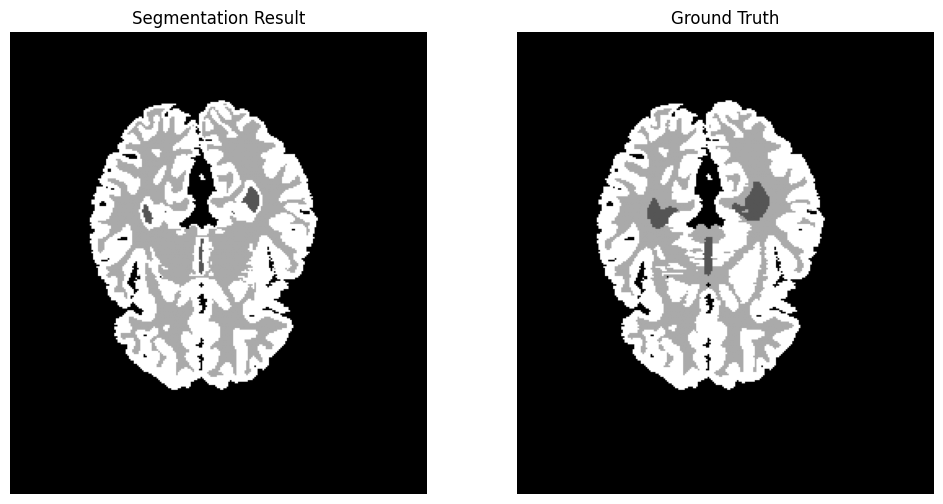

In [22]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/kmeans_em_results/kmeans_em_segmented_1005.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1005_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

### **Tissue Model Initilization**

In [23]:
def tissue_model_segmentation_with_em(image_folder, mask_folder, label_folder, output_folder, tissue_model_folder, num_bins=4096):
  # Load the tissue model probabilities
  tissue_model_probs = load_tissue_model(tissue_model_folder)
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  # Load paths for test images, masks, and labels
  image_paths = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.nii.gz')])
  mask_paths = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith('.nii.gz')])
  label_paths = sorted([os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.nii.gz')])

  for img_path, mask_path, lbl_path in zip(image_paths, mask_paths, label_paths):
    # Load test image, mask, and ground truth label
    test_img = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    mask_img = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool)
    label_img = sitk.GetArrayFromImage(sitk.ReadImage(lbl_path))

    # Scale the test image for histogram-based probabilities
    test_img_scaled = min_max_scaler(test_img, num_bins - 1).astype(np.uint16)

    # Get tissue model probabilities
    cond_prob_csf = tissue_model_probs[0, test_img_scaled]
    cond_prob_wm = tissue_model_probs[1, test_img_scaled]
    cond_prob_gm = tissue_model_probs[2, test_img_scaled]

    # Initial segmentation using maximum probability from tissue model
    stacked_probs = np.stack([cond_prob_csf, cond_prob_wm, cond_prob_gm], axis=0)
    initial_labels = np.argmax(stacked_probs, axis=0) + 1  # Label convention (1: CSF, 2: WM, 3: GM)
    initial_labels[~mask_img] = 0  # Apply mask to exclude non-brain areas

    # Refine segmentation with EM
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_tissue_segmentation(test_img, initial_labels)

    # Assign final labels based on EM output
    em_prob_stack = np.stack([EM_csf_prob, EM_wm_prob, EM_gm_prob], axis=-1)
    segmented_img = np.argmax(em_prob_stack, axis=-1) + 1  # Label convention (1: CSF, 2: WM, 3: GM)
    segmented_img[~mask_img] = 0  # Apply mask to exclude non-brain areas

    # Calculate Dice Similarity Coefficients for CSF, WM, and GM
    dice_csf = dice_coefficient(segmented_img, label_img, label=1)  # CSF
    dice_wm = dice_coefficient(segmented_img, label_img, label=2)   # WM
    dice_gm = dice_coefficient(segmented_img, label_img, label=3)   # GM
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f'Dice Scores for {os.path.basename(img_path)}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}')

    # Save segmented image
    save_segmented_image(segmented_img,  img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)

  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)

  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)

  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

# Define folders

output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/"

tissue_model_segmentation_with_em(test_image_folder, mask_folder, ground_truth_folder, output_folder, tissue_model_folder)


Dice Scores for 1003.nii.gz: CSF 0.039, WM 0.883, GM 0.825
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.018, WM 0.814, GM 0.640
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.783, WM 0.897, GM 0.930
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.255, WM 0.908, GM 0.908
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.052, WM 0.863, GM 0.775
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1019.nii.gz

Dice Score

Segmentation Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


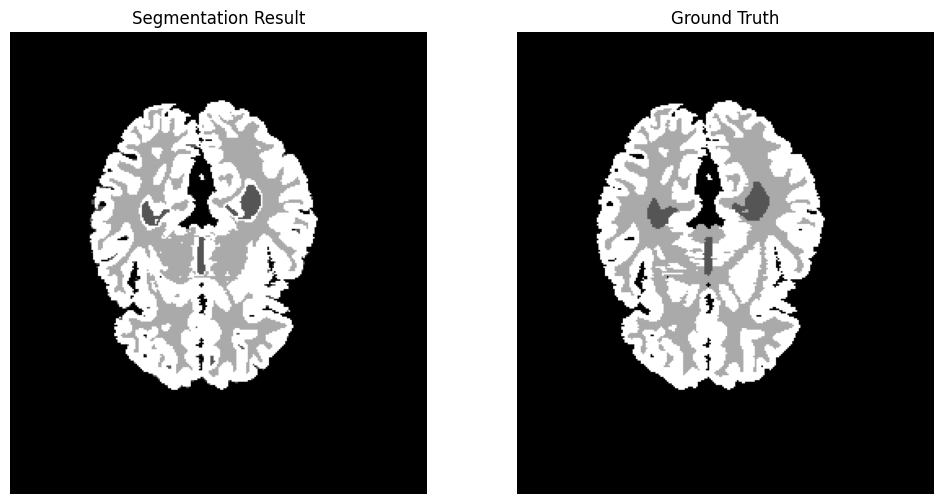

In [24]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_with_em_1005.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1005_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

### **EM using Label Propagation Initialization**

In [25]:
def segment_with_label_propagation_and_em(test_image_paths, csf_folder, wm_folder, gm_folder, mask_paths, ground_truth_paths, output_folder):
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  for test_image_path in test_image_paths:
    # Get the base filename for matching probability maps
    test_filename = os.path.basename(test_image_path).split('.')[0]  # Extract '1003' from '1003.nii.gz'
    # Match the corresponding probability maps
    csf_path = os.path.join(csf_folder, f"{test_filename}_csf.nii")
    wm_path = os.path.join(wm_folder, f"{test_filename}_wm.nii")
    gm_path = os.path.join(gm_folder, f"{test_filename}_gm.nii")

    if not (os.path.exists(csf_path) and os.path.exists(wm_path) and os.path.exists(gm_path)):
      print(f"Probability maps for {test_filename} not found. Skipping...")
      continue
    # Load the transformed probability maps
    csf_prob_map = sitk.ReadImage(csf_path)
    wm_prob_map = sitk.ReadImage(wm_path)
    gm_prob_map = sitk.ReadImage(gm_path)

    csf_array = sitk.GetArrayFromImage(csf_prob_map)
    wm_array = sitk.GetArrayFromImage(wm_prob_map)
    gm_array = sitk.GetArrayFromImage(gm_prob_map)

    # Load mask and apply if available
    if mask_paths:
      mask_path = next((m for m in mask_paths if test_filename in m), None)
      mask_array = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool) if mask_path else np.ones_like(csf_array, dtype=bool)
    else:
      mask_array = np.ones_like(csf_array, dtype=bool)

    # Initial segmentation using label propagation
    stacked_probs = np.stack([csf_array, wm_array, gm_array], axis=0)
    initial_labels = np.argmax(stacked_probs, axis=0) + 1  # Label convention (1: CSF, 2: WM, 3: GM)
    initial_labels[~mask_array] = 0

    # Refine with EM
    test_image = sitk.GetArrayFromImage(sitk.ReadImage(test_image_path))
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_tissue_segmentation(test_image, initial_labels)

    # Get final labels after EM refinement
    em_prob_stack = np.stack([EM_csf_prob, EM_wm_prob, EM_gm_prob], axis=-1)
    final_labels = np.argmax(em_prob_stack, axis=-1) + 1  # Apply label convention
    final_labels[~mask_array] = 0
    #Save segmented result
    save_segmented_image(final_labels,  test_image_path, output_folder)
    # Compute Dice scores if ground truth is available
    if ground_truth_paths:
      ground_truth_path = next((g for g in ground_truth_paths if test_filename in g), None)
      if ground_truth_path:
        ground_truth = sitk.ReadImage(ground_truth_path)
        ground_truth_array = sitk.GetArrayFromImage(ground_truth)

        dice_csf = dice_coefficient(final_labels, ground_truth_array, label=1)
        dice_wm = dice_coefficient(final_labels, ground_truth_array, label=2)
        dice_gm = dice_coefficient(final_labels, ground_truth_array, label=3)
            # Store Dice scores in the respective lists
        dice_scores_csf.append(dice_csf)
        dice_scores_wm.append(dice_wm)
        dice_scores_gm.append(dice_gm)
        # Display Dice scores for each class in one line
        print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}\n")
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)
  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)
  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)
  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

# Collect file paths for test images, masks, and ground truth
test_image_paths = sorted([os.path.join(test_image_folder, f) for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
mask_paths = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith(".nii.gz")]) if os.path.exists(mask_folder) else None
ground_truth_paths = sorted([os.path.join(ground_truth_folder, f) for f in os.listdir(ground_truth_folder) if f.endswith(".nii.gz")])

segment_with_label_propagation_and_em(test_image_paths, csf_folder, wm_folder, gm_folder, mask_paths, ground_truth_paths, output_folder)


Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1003.nii.gz

Dice Scores for 1003: CSF 0.000, WM 0.896, GM 0.921

Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1004.nii.gz

Dice Scores for 1004: CSF 0.659, WM 0.906, GM 0.927

Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1005.nii.gz

Dice Scores for 1005: CSF 0.878, WM 0.855, GM 0.889

Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1018.nii.gz

Dice Scores for 1018: CSF 0.452, WM 0.901, GM 0.924

Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_em_segmentation_results/segmented_1019.nii.gz

Dice Scores for 1019: CSF 0.000, WM 0.852, GM 0.890

Segmented image saved to /content/drive/

Segmentation Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


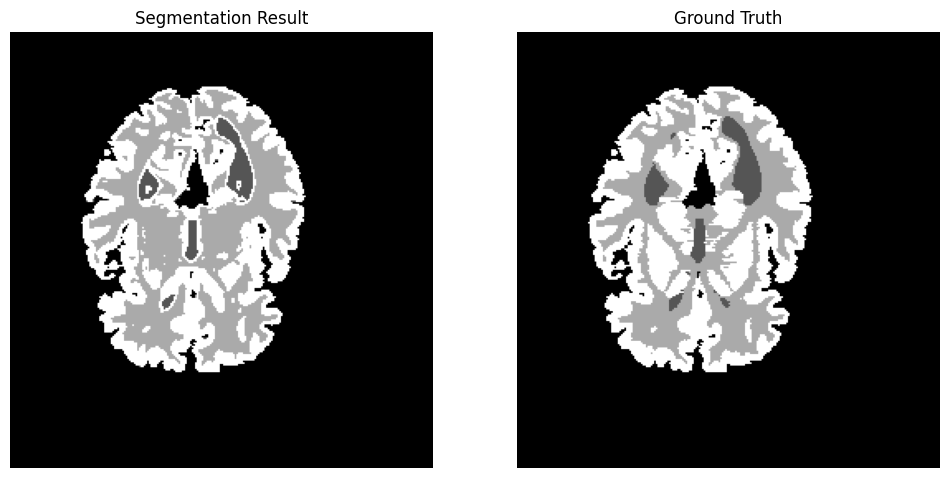

In [ ]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_em_results/segmented_with_em_1125.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1125_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

### **Tissue Model and Label Propagation with EM**

In [26]:
def tissue_model_with_label_propagation_em_v2(
    test_image_folder, mask_folder, label_folder, output_folder, tissue_model_path, csf_folder, wm_folder, gm_folder, num_bins=4096
):
  """
  Perform segmentation using tissue models and label propagation with EM refinement.
  """
  # Load the tissue model probabilities
  tissue_model_distributions = load_tissue_model(tissue_model_folder)
  csf_model, wm_model, gm_model = (
      tissue_model_distributions[0],  # CSF distribution
      tissue_model_distributions[1],  # WM distribution
      tissue_model_distributions[2],  # GM distribution
  )
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  # Load paths for test images, masks, and labels
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  csf_files = sorted([os.path.join(csf_folder, f) for f in os.listdir(csf_folder) if f.endswith(".nii")])
  wm_files = sorted([os.path.join(wm_folder, f) for f in os.listdir(wm_folder) if f.endswith(".nii")])
  gm_files = sorted([os.path.join(gm_folder, f) for f in os.listdir(gm_folder) if f.endswith(".nii")])

  for i, test_filename in enumerate(test_files):
    # Load the test image, mask, and label
    test_img_path = os.path.join(test_image_folder, test_filename)
    mask_path = os.path.join(mask_folder, mask_files[i])
    label_path = os.path.join(label_folder, label_files[i])

    test_img = sitk.GetArrayFromImage(sitk.ReadImage(test_img_path)).astype(np.float32)
    mask_array = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool)
    label_img = sitk.GetArrayFromImage(sitk.ReadImage(label_path))

    # Apply mask to define ROI
    test_img[~mask_array] = 0

    # Normalize intensities to fit within histogram bins
    max_intensity = len(csf_model) - 1
    test_img_scaled = np.clip(test_img, 0, max_intensity).astype(np.uint16)

    # Compute conditional probabilities from tissue models
    cond_prob_csf = csf_model[test_img_scaled]
    cond_prob_wm = wm_model[test_img_scaled]
    cond_prob_gm = gm_model[test_img_scaled]

    # Load atlas probability maps for this test image
    csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(csf_files[i]))
    wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(wm_files[i]))
    gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(gm_files[i]))

    # Combine tissue model probabilities with atlas probabilities
    combined_prob_csf = cond_prob_csf * csf_prob_map
    combined_prob_wm = cond_prob_wm * wm_prob_map
    combined_prob_gm = cond_prob_gm * gm_prob_map

    # Initial segmentation using maximum combined probability
    stacked_probs = np.stack([combined_prob_csf, combined_prob_wm, combined_prob_gm], axis=0)
    initial_labels = np.argmax(stacked_probs, axis=0) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    initial_labels[~mask_array] = 0

    # Refine with EM
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_tissue_segmentation(test_img, initial_labels)

    # Multiply EM probabilities with atlas probabilities
    EM_csf_prob *= csf_prob_map
    EM_wm_prob *= wm_prob_map
    EM_gm_prob *= gm_prob_map

    # Final segmentation using maximum combined probability
    final_probs = np.stack([EM_csf_prob, EM_wm_prob, EM_gm_prob], axis=0)
    final_labels = np.argmax(final_probs, axis=0) + 1  # +1 for label convention
    final_labels[~mask_array] = 0

    # Compute Dice scores for CSF, WM, and GM
    dice_csf = dice_coefficient(final_labels, label_img, label=1)
    dice_wm = dice_coefficient(final_labels, label_img, label=2)
    dice_gm = dice_coefficient(final_labels, label_img, label=3)
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")
    save_segmented_image(final_labels,   test_img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)
  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)
  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)
  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")


# Define the paths

output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/"

# Run the segmentation
tissue_model_with_label_propagation_em_v2(
    test_image_folder, mask_folder, ground_truth_folder, output_folder, tissue_model_folder, csf_folder, wm_folder, gm_folder
)


Dice Scores for 1003.nii.gz: CSF 0.223, WM 0.768, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.317, WM 0.777, GM 0.796
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.584, WM 0.742, GM 0.782
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.341, WM 0.766, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.292, WM 0.749, GM 0.791
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/test-set/tissue_model_label_propagation_em_results/segmente

Segmentation Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -141.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


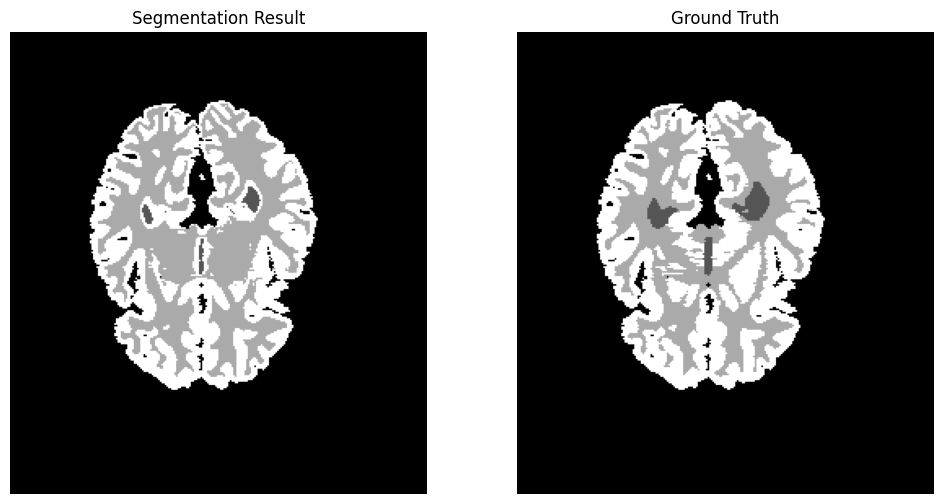

In [ ]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_em_results/segmented_with_em_1005.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1005_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

### **Segment_with_K-Means_EM_Atlas**

In [27]:
def segment_with_kmeans_em_atlas(test_image_folder, label_folder, mask_folder, csf_folder, wm_folder, gm_folder, output_folder):
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []
  # Load test image, label, and mask files
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])
  # Iterate through each test image
  for i, test_filename in enumerate(test_files):
    # Extract numeric part to find corresponding files
    numeric_part = extract_numeric_part(test_filename)
    # Find corresponding label, mask, and atlas files
    label_file = next((f for f in label_files if numeric_part in extract_numeric_part(f) and '3C' in f), None)
    mask_file = next((f for f in mask_files if numeric_part in extract_numeric_part(f) and '1C' in f), None)
    atlas_csf_file = os.path.join(csf_folder, f"{numeric_part}_csf.nii")
    atlas_wm_file = os.path.join(wm_folder, f"{numeric_part}_wm.nii")
    atlas_gm_file = os.path.join(gm_folder, f"{numeric_part}_gm.nii")

    if not label_file or not mask_file or not os.path.exists(atlas_csf_file) or not os.path.exists(atlas_wm_file) or not os.path.exists(atlas_gm_file):
        print(f"Warning: Missing label, mask, or atlas files for {test_filename}. Skipping...")
        continue
    # Load the test image, labels, mask, and atlas probabilities
    test_img_path = os.path.join(test_image_folder, test_filename)
    label_img_path = os.path.join(label_folder, label_file)
    mask_img_path = os.path.join(mask_folder, mask_file)

    test_img = sitk.GetArrayFromImage(sitk.ReadImage(test_img_path)).astype(np.float32)
    test_labels = sitk.GetArrayFromImage(sitk.ReadImage(label_img_path))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_img_path)).astype(bool)

    atlas_csf = sitk.GetArrayFromImage(sitk.ReadImage(atlas_csf_file))
    atlas_wm = sitk.GetArrayFromImage(sitk.ReadImage(atlas_wm_file))
    atlas_gm = sitk.GetArrayFromImage(sitk.ReadImage(atlas_gm_file))

    # Apply mask to the test image
    test_img[~mask] = 0
    # Logarithmic transformation and normalization
    test_img_log = np.log1p(test_img)  # log(1 + intensity)
    test_img_scaled = min_max_scaler(test_img_log, max_val=255.0)
    # K-means clustering for initialization
    roi_indices = np.where(mask)
    test_img_roi = test_img_scaled[roi_indices].reshape(-1, 1)

    kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++')
    kmeans_labels = kmeans.fit_predict(test_img_roi)

    initial_labels = np.zeros_like(test_img, dtype=int)
    initial_labels[roi_indices] = kmeans_labels + 1  # +1 to match label convention
    initial_labels[~mask] = 0

    # Apply EM refinement
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_tissue_segmentation(test_img, initial_labels)

    # Combine atlas probabilities with EM probabilities
    combined_prob_csf = EM_csf_prob * atlas_csf
    combined_prob_wm = EM_wm_prob * atlas_wm
    combined_prob_gm = EM_gm_prob * atlas_gm

    # Assign labels based on the maximum combined probability
    prob_stack = np.stack([combined_prob_csf, combined_prob_wm, combined_prob_gm], axis=-1)
    final_labels = np.argmax(prob_stack, axis=-1) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    final_labels[~mask] = 0  # Apply mask to exclude non-brain areas

    # Compute Dice scores for CSF, WM, and GM
    dice_csf = dice_coefficient(final_labels, test_labels, label=1)
    dice_wm = dice_coefficient(final_labels, test_labels, label=2)
    dice_gm = dice_coefficient(final_labels, test_labels, label=3)
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)

    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")

    # Save the segmented image
    save_segmented_image(final_labels, test_img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)
  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)
  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)
  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")
# Define output folder
output_folder = "/content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/"

# Run segmentation with K-means, EM refinement, and atlas integration
segment_with_kmeans_em_atlas(
   test_image_folder,
   ground_truth_folder,
   mask_folder,
   csf_folder,
    wm_folder,
    gm_folder,
    output_folder
)


Dice Scores for 1003.nii.gz: CSF 0.223, WM 0.768, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.317, WM 0.777, GM 0.796
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.584, WM 0.742, GM 0.782
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.341, WM 0.766, GM 0.793
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.292, WM 0.749, GM 0.791
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MISA/segment_with_kmeans_em_atlas/segmented_1019.nii.gz

Dice Scores for 1023.nii.gz: CSF 0.222, WM 0.778, GM 0.803
Segmented image saved to /content/dr

Segmentation Image Info:
(-127.5, 127.5, -153.0) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -153.0) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


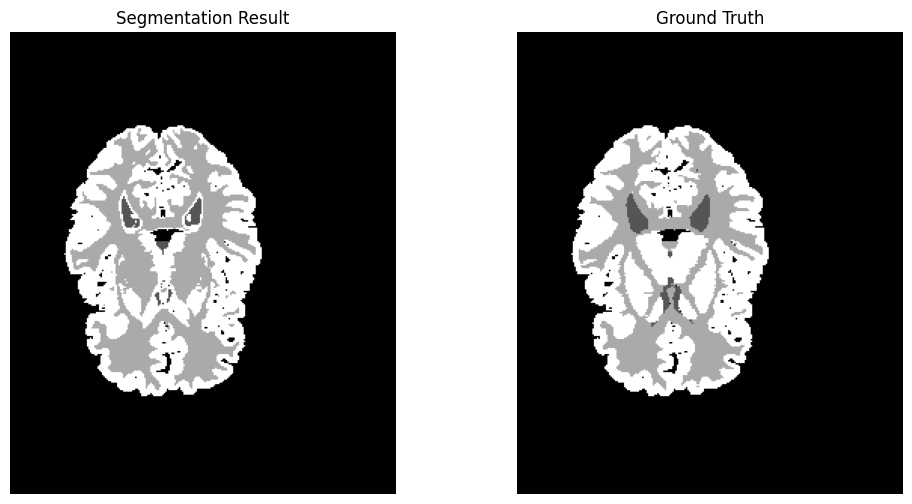

In [ ]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/label_propagation_em_results/segmented_with_em_1101.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1101_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

## **APosteriori (After Algorithm Convergence)**

In [ ]:
def em_with_combined_atlas_aposteriori(
    test_image_folder,
    mask_folder,
    label_folder,
    output_folder,
    tissue_model_path,
    csf_folder,
    wm_folder,
    gm_folder,
    mni_csf_folder,
    mni_wm_folder,
    mni_gm_folder,
    num_bins=4096
):
  """
  Perform EM segmentation and refine the results a posteriori using both user and MNI atlas probabilities.
  """
  # Load the tissue model probabilities
  tissue_model_distributions = load_tissue_model(tissue_model_folder)
  csf_model, wm_model, gm_model = (
      tissue_model_distributions[0],  # CSF distribution
      tissue_model_distributions[1],  # WM distribution
      tissue_model_distributions[2],  # GM distribution
  )
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  # Load paths for test images, masks, and labels
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  csf_files = sorted([os.path.join(csf_folder, f) for f in os.listdir(csf_folder) if f.endswith(".nii")])
  wm_files = sorted([os.path.join(wm_folder, f) for f in os.listdir(wm_folder) if f.endswith(".nii")])
  gm_files = sorted([os.path.join(gm_folder, f) for f in os.listdir(gm_folder) if f.endswith(".nii")])
  mni_csf_files = sorted([os.path.join(mni_csf_folder, f) for f in os.listdir(mni_csf_folder) if f.endswith(".nii")])
  mni_wm_files = sorted([os.path.join(mni_wm_folder, f) for f in os.listdir(mni_wm_folder) if f.endswith(".nii")])
  mni_gm_files = sorted([os.path.join(mni_gm_folder, f) for f in os.listdir(mni_gm_folder) if f.endswith(".nii")])

  for i, test_filename in enumerate(test_files):
    # Load the test image, mask, and label
    test_img_path = os.path.join(test_image_folder, test_filename)
    mask_path = os.path.join(mask_folder, mask_files[i])
    label_path = os.path.join(label_folder, label_files[i])

    test_img = sitk.GetArrayFromImage(sitk.ReadImage(test_img_path)).astype(np.float32)
    mask_array = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool)
    label_img = sitk.GetArrayFromImage(sitk.ReadImage(label_path))

    # Apply mask to define ROI
    test_img[~mask_array] = 0

    # Normalize intensities to fit within histogram bins
    max_intensity = len(csf_model) - 1
    test_img_scaled = np.clip(test_img, 0, max_intensity).astype(np.uint16)

    # Compute conditional probabilities from tissue models
    cond_prob_csf = csf_model[test_img_scaled]
    cond_prob_wm = wm_model[test_img_scaled]
    cond_prob_gm = gm_model[test_img_scaled]

    # Load user atlas probability maps
    csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(csf_files[i]))
    wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(wm_files[i]))
    gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(gm_files[i]))

    # Combine tissue model probabilities with user atlas probabilities
    combined_prob_csf = cond_prob_csf * csf_prob_map
    combined_prob_wm = cond_prob_wm * wm_prob_map
    combined_prob_gm = cond_prob_gm * gm_prob_map

    # Initial segmentation using maximum combined probability
    stacked_probs = np.stack([combined_prob_csf, combined_prob_wm, combined_prob_gm], axis=0)
    initial_labels = np.argmax(stacked_probs, axis=0) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    initial_labels[~mask_array] = 0

    # Refine with EM (using user atlas probabilities only)
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_segmentation_with_atlas(test_img, initial_labels, csf_prob_map, wm_prob_map, gm_prob_map)

    # Apply MNI atlas probabilities a posteriori
    mni_csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_csf_files[i]))
    mni_wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_wm_files[i]))
    mni_gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_gm_files[i]))

    final_csf_prob = EM_csf_prob * mni_csf_prob_map
    final_wm_prob = EM_wm_prob * mni_wm_prob_map
    final_gm_prob = EM_gm_prob * mni_gm_prob_map

    # Final segmentation using maximum combined probability
    final_probs = np.stack([final_csf_prob, final_wm_prob, final_gm_prob], axis=0)
    final_labels = np.argmax(final_probs, axis=0) + 1  # +1 for label convention
    final_labels[~mask_array] = 0

    # Compute Dice scores for CSF, WM, and GM
    dice_csf = dice_coefficient(final_labels, label_img, label=1)
    dice_wm = dice_coefficient(final_labels, label_img, label=2)
    dice_gm = dice_coefficient(final_labels, label_img, label=3)
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")
    # Save segmented image
    save_segmented_image(final_labels,  test_img_path , output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)
  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)
  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)
  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

output_folder_aposteriori = "/content/drive/My Drive/Colab Notebooks/MISA/test-set/combined_atlas_aposteriori_results/"
em_with_combined_atlas_aposteriori(
    test_image_folder,
    mask_folder,
    ground_truth_folder,
    output_folder_aposteriori,
    tissue_model_folder,
    csf_folder,
    wm_folder,
    gm_folder,
    mni_csf_folder,
    mni_wm_folder,
    mni_gm_folder,
    num_bins=4096
)


Dice Scores for 1003.nii.gz: CSF 0.110, WM 0.901, GM 0.930
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_aposteriori_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.187, WM 0.899, GM 0.920
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_aposteriori_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.531, WM 0.883, GM 0.917
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_aposteriori_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.201, WM 0.896, GM 0.925
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_aposteriori_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.104, WM 0.884, GM 0.923
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_aposteriori_results/seg

Segmentation Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


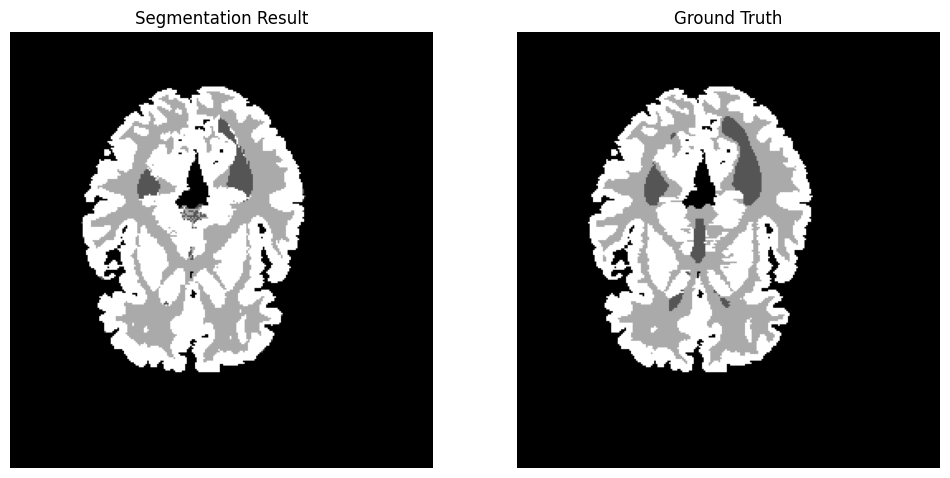

In [ ]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/combined_atlas_aposteriori_results/combined_atlas_aposteriori_1125.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1125_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)

###MNI atlas information Into EM

In [ ]:
def em_with_combined_atlas_into_em_v2(
  test_image_folder,
  mask_folder,
  label_folder,
  output_folder,
  tissue_model_path,
  csf_folder,
  wm_folder,
  gm_folder,
  mni_csf_folder,
  mni_wm_folder,
  mni_gm_folder,
  update_frequency=2,
  num_bins=4096
):
  """
  Perform EM segmentation while integrating atlas and MNI atlas information into EM iterations.
  """
  # Load the tissue model probabilities
  tissue_model_distributions = load_tissue_model(tissue_model_folder)
  csf_model, wm_model, gm_model = (
      tissue_model_distributions[0],  # CSF distribution
      tissue_model_distributions[1],  # WM distribution
      tissue_model_distributions[2],  # GM distribution
  )
  os.makedirs(output_folder, exist_ok=True)
  dice_scores_csf = []
  dice_scores_wm = []
  dice_scores_gm = []

  # Load paths for test images, masks, and labels
  test_files = sorted([f for f in os.listdir(test_image_folder) if f.endswith(".nii.gz")])
  mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".nii.gz")])
  label_files = sorted([f for f in os.listdir(label_folder) if f.endswith(".nii.gz")])
  csf_files = sorted([os.path.join(csf_folder, f) for f in os.listdir(csf_folder) if f.endswith(".nii")])
  wm_files = sorted([os.path.join(wm_folder, f) for f in os.listdir(wm_folder) if f.endswith(".nii")])
  gm_files = sorted([os.path.join(gm_folder, f) for f in os.listdir(gm_folder) if f.endswith(".nii")])
  mni_csf_files = sorted([os.path.join(mni_csf_folder, f) for f in os.listdir(mni_csf_folder) if f.endswith(".nii")])
  mni_wm_files = sorted([os.path.join(mni_wm_folder, f) for f in os.listdir(mni_wm_folder) if f.endswith(".nii")])
  mni_gm_files = sorted([os.path.join(mni_gm_folder, f) for f in os.listdir(mni_gm_folder) if f.endswith(".nii")])

  for i, test_filename in enumerate(test_files):
    # Load the test image, mask, and label
    test_img_path = os.path.join(test_image_folder, test_filename)
    mask_path = os.path.join(mask_folder, mask_files[i])
    label_path = os.path.join(label_folder, label_files[i])

    test_img = sitk.GetArrayFromImage(sitk.ReadImage(test_img_path)).astype(np.float32)
    mask_array = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(bool)
    label_img = sitk.GetArrayFromImage(sitk.ReadImage(label_path))

    # Apply mask to define ROI
    test_img[~mask_array] = 0

    # Normalize intensities to fit within histogram bins
    max_intensity = len(csf_model) - 1
    test_img_scaled = np.clip(test_img, 0, max_intensity).astype(np.uint16)

    # Compute conditional probabilities from tissue models
    cond_prob_csf = csf_model[test_img_scaled]
    cond_prob_wm = wm_model[test_img_scaled]
    cond_prob_gm = gm_model[test_img_scaled]

    # Load user atlas probability maps
    csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(csf_files[i]))
    wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(wm_files[i]))
    gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(gm_files[i]))

    # Combine tissue model probabilities with user atlas probabilities
    combined_prob_csf = cond_prob_csf * csf_prob_map
    combined_prob_wm = cond_prob_wm * wm_prob_map
    combined_prob_gm = cond_prob_gm * gm_prob_map

    # Initial segmentation using maximum combined probability
    stacked_probs = np.stack([combined_prob_csf, combined_prob_wm, combined_prob_gm], axis=0)
    initial_labels = np.argmax(stacked_probs, axis=0) + 1  # +1 for label convention (1: CSF, 2: WM, 3: GM)
    initial_labels[~mask_array] = 0

    # Load MNI atlas probabilities
    mni_csf_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_csf_files[i]))
    mni_wm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_wm_files[i]))
    mni_gm_prob_map = sitk.GetArrayFromImage(sitk.ReadImage(mni_gm_files[i]))

    # Refine with EM and integrate MNI atlas during specific iterations
    EM_csf_prob, EM_wm_prob, EM_gm_prob, _ = em_segmentation_with_atlas(
        test_img, initial_labels, mni_csf_prob_map, mni_wm_prob_map, mni_gm_prob_map, update_frequency
    )

    # Final segmentation using maximum combined probability
    final_probs = np.stack([EM_csf_prob, EM_wm_prob, EM_gm_prob], axis=0)
    final_labels = np.argmax(final_probs, axis=0) + 1  # +1 for label convention
    final_labels[~mask_array] = 0

    # Compute Dice scores for CSF, WM, and GM
    dice_csf = dice_coefficient(final_labels, label_img, label=1)
    dice_wm = dice_coefficient(final_labels, label_img, label=2)
    dice_gm = dice_coefficient(final_labels, label_img, label=3)
    # Store Dice scores in the respective lists
    dice_scores_csf.append(dice_csf)
    dice_scores_wm.append(dice_wm)
    dice_scores_gm.append(dice_gm)
    print(f"Dice Scores for {test_filename}: CSF {dice_csf:.3f}, WM {dice_wm:.3f}, GM {dice_gm:.3f}")
    # Save segmented image
    save_segmented_image(final_labels,  test_img_path, output_folder)
  # Calculate mean and standard deviation for each tissue
  mean_csf = np.mean(dice_scores_csf)
  std_csf = np.std(dice_scores_csf)
  mean_wm = np.mean(dice_scores_wm)
  std_wm = np.std(dice_scores_wm)
  mean_gm = np.mean(dice_scores_gm)
  std_gm = np.std(dice_scores_gm)
  print("\nOverall Dice Scores:")
  print(f"CSF: Mean = {mean_csf:.3f}, Std = {std_csf:.3f}")
  print(f"WM: Mean = {mean_wm:.3f}, Std = {std_wm:.3f}")
  print(f"GM: Mean = {mean_gm:.3f}, Std = {std_gm:.3f}")

output_folder_into_em = "/content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/"
em_with_combined_atlas_into_em_v2(
    test_image_folder,
    mask_folder,
    ground_truth_folder,
    output_folder_into_em,
    tissue_model_folder,
    csf_folder,
    wm_folder,
    gm_folder,
    mni_csf_folder,
    mni_wm_folder,
    mni_gm_folder,
    update_frequency=5,  # 2
    num_bins=4096
)

Dice Scores for 1003.nii.gz: CSF 0.069, WM 0.813, GM 0.891
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/segmented_1003.nii.gz

Dice Scores for 1004.nii.gz: CSF 0.169, WM 0.827, GM 0.889
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/segmented_1004.nii.gz

Dice Scores for 1005.nii.gz: CSF 0.538, WM 0.814, GM 0.887
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/segmented_1005.nii.gz

Dice Scores for 1018.nii.gz: CSF 0.189, WM 0.823, GM 0.893
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/segmented_1018.nii.gz

Dice Scores for 1019.nii.gz: CSF 0.062, WM 0.829, GM 0.903
Segmented image saved to /content/drive/My Drive/Colab Notebooks/MAIA M2/MISA/test-set/combined_atlas_into_em_results/segmented_1019.nii.gz



Segmentation Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Ground Truth Image Info:
(-127.5, 127.5, -131.5) (1.0, 1.0, 1.0) (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


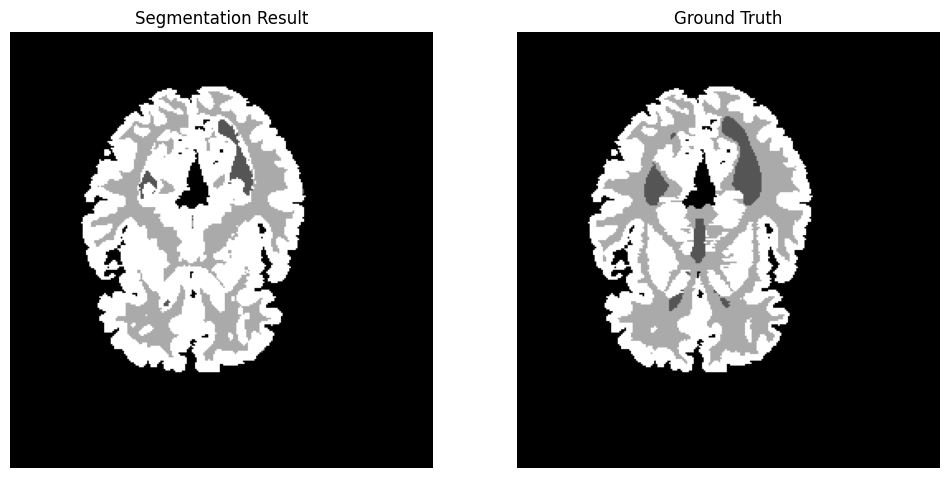

In [ ]:
segmentation_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/combined_atlas_into_em_results/combined_atlas_into_em_1125.nii.gz'
ground_truth_path = '/content/drive/My Drive/Colab Notebooks/MISA/test-set/testing-labels/1125_3C.nii.gz'

# Call the function to display the segmentation and ground truth images using the center slice (default)
display_segmentation_and_ground_truth(segmentation_path, ground_truth_path)